# 1D Structure Function / Mooring Data

This example will guide you through each step necessary to compute scalar-based structure functions from a 1D time series of ocean currents.

$\textbf{General procedure}:$


1 -  Load the dataset, it can retrieved from https://www.ncei.noaa.gov

2 -  Format dataset to match pyturbo_sf inputs if necessary

3 -  Calculate second-order zonal current structure function as a function of separation time

4 -  Quick comparison between no bootstrapping and bootstrapping in 1D - which shows in this specific case the inefficiency of pyturbo_sf (check executed time)

5 -  Plot the 1D SF 

$\textbf{Motivation:}$ This example shows the 1D structure function computation using pyturbo_sf on time series. The 1D structure function might reveal some time scales at which turbulent energy is transferred in the ocean.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import numpy as np
import datetime
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load Mooring Dataset

In [2]:
ds = xr.open_dataset('/home/aayouche/Downloads/gocd_a0060062_7922vm-a.nc')


# Assuming your array is called 'julian_dates'
# Method 1: List comprehension
datetime_dates = [datetime.datetime(dt.year, dt.month, dt.day, 
                                   dt.hour, dt.minute, dt.second, 
                                   dt.microsecond) for dt in ds.time.values]

# Convert back to numpy array if needed
datetime_array = np.array(datetime_dates, dtype='datetime64[us]')

# Convert the time differences to seconds
# First, convert to timedelta64[s] type
delta_seconds = (datetime_array - datetime_array[0]).astype('timedelta64[s]')

# Then convert to floating point numbers representing seconds
delta_seconds_float = delta_seconds.astype(float)

dt_min = 60.0
dt_max = delta_seconds_float.max()
ds

<xarray.Dataset> Size: 436kB
Dimensions:                 (time: 10898)
Coordinates:
  * time                    (time) object 87kB 2005-06-06 13:01:29.999981 ......
    depth                   float32 4B ...
    latitude                float32 4B ...
    longitude               float32 4B ...
Data variables:
    crs                     int32 4B ...
    depth_quality_flag      float64 8B ...
    latitude_quality_flag   float64 8B ...
    longitude_quality_flag  float64 8B ...
    seafloor_depth          float32 4B ...
    time_quality_flag       (time) float64 87kB ...
    u                       (time) float32 44kB ...
    u_quality_flag          (time) float64 87kB ...
    v                       (time) float32 44kB ...
    v_quality_flag          (time) float64 87kB ...
Attributes: (12/72)
    acknowledgment:                  The most important contributors are the ...
    cdm_data_type:                   Station
    comment:                         Data that have been undergone additional...
    contributor_name:                B. Butman, M. Bothner, and R. Signell
    contributor_role:                data originator
    Conventions:                     CF-1.6, ACDD-1.3
    ...                              ...
    QC_test_names:                   Platform_Identification, Impossible_Date...
    QC_test_codes:                   1, 1, 1, 1, 1, 1, 1, 1, 1
    QC_test_results:                 1, 1, 1, 2, 1, 1, 1, 1, 1
    QC_indicator:                    2
    QC_Software:                     qcscd.R, 1.3, 2015-03-09
    uuid:                            fb9c3b81-f3da-4043-bb05-1e48f51649b7

# Make A quick plot


/tmp/ipykernel_174930/3979089935.py:2: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(datetime_array,ds.u.values)


Text(0, 0.5, 'u\xa0[m/s]')

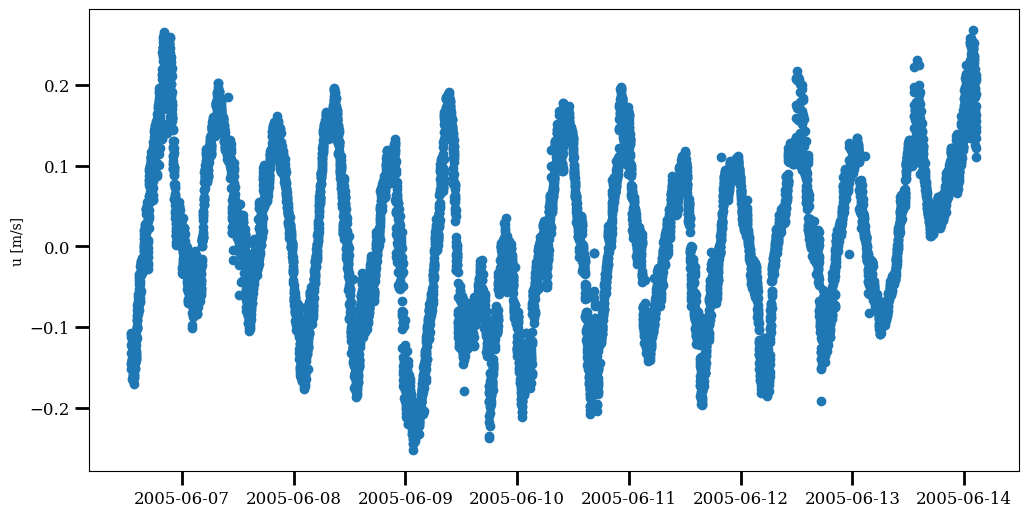

In [3]:
plt.figure(figsize=(12,6))
plt.plot_date(datetime_array,ds.u.values)
plt.ylabel('u [m/s]')


# Format Dataset

In [4]:
# Create the xarray dataset
ds_new = xr.Dataset({
    'u': ('time', ds.u.values), 
    'v': ('time', ds.v.values),
}, coords={
    'time': ('time', datetime_array),
})

In [5]:
ds_new

<xarray.Dataset> Size: 174kB
Dimensions:  (time: 10898)
Coordinates:
  * time     (time) datetime64[us] 87kB 2005-06-06T13:01:29.999981 ... 2005-0...
Data variables:
    u        (time) float32 44kB -0.1092 -0.1074 -0.1121 ... 0.1221 0.143 0.1627
    v        (time) float32 44kB -0.121 -0.1255 -0.1168 ... 0.04732 0.04929

# Common parameters for structure function calculations

In [ ]:

bin_time = np.logspace(np.log10(dt_min), np.log10(653819.0), 10)
bins = {'time': bin_time}

sf_kwargs = {
    "ds": ds_new,
    "variables_names": ["u"],
    "order": 2,
    "bins": bins,
    "fun": 'scalar',
    "initial_nbootstrap": 100,
    "max_nbootstrap": 200,
    "step_nbootstrap": 50,
    "convergence_eps": 0.02,
    "n_jobs": -1,
    "backend": 'loky',
    "seed": 42
}

# Compute second order zonal velocity SF (no bootstrapping) - bootsize = 10898

In [6]:
%%time

iso_sf_lon = psf.bin_sf_1d(
    bootsize={'time': 10898},
    **sf_kwargs
)

Data dimensions and shapes: {'time': 10898}
Using bootsize: {'time': 10898}
Dimension time has bootsize equal to or larger than dimension size. No bootstrapping will be done across this dimension.
No bootstrappable dimensions available. Structure functions will be calculated using the full dataset without bootstrapping or spacings.

STARTING BIN_SF WITH FUNCTION TYPE: scalar
Variables: ['u'], Order: 2
Bootstrap parameters: initial=100, max=200, step=50
Convergence threshold: 0.02
Confidence level: 0.95
Bootstrappable dimensions: [] (count: 0)
Using volume element weighting: |dx|

Detected logarithmic binning for dimension 'time'

No bootstrappable dimensions available. Calculating structure function once with full dataset.
1D SF COMPLETED SUCCESSFULLY (no bootstrapping)!
CPU times: user 816 ms, sys: 1.01 ms, total: 817 ms
Wall time: 815 ms


# Compute second order zonal velocity SF - bootsize = 170

In [7]:
%%time

iso_sf_lon = psf.bin_sf_1d(
    bootsize={'time': 170},
    **sf_kwargs
)

Data dimensions and shapes: {'time': 10898}
Using bootsize: {'time': 170}
Accessible spacings are: [1, 2, 4, 8, 16, 32, 64]

STARTING BIN_SF WITH FUNCTION TYPE: scalar
Variables: ['u'], Order: 2
Bootstrap parameters: initial=100, max=200, step=50
Convergence threshold: 0.02
Confidence level: 0.95
Bootstrappable dimensions: ['time'] (count: 1)
Using volume element weighting: |dx|

Detected logarithmic binning for dimension 'time'
Available spacings: [1, 2, 4, 8, 16, 32, 64]

INITIAL BOOTSTRAP PHASE
  Processing spacing 1 with 14 bootstraps
  Processing spacing 2 with 14 bootstraps
  Processing spacing 4 with 14 bootstraps
  Processing spacing 8 with 14 bootstraps
  Processing spacing 16 with 14 bootstraps
  Processing spacing 32 with 14 bootstraps
  Processing spacing 64 with 14 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 286076
Bins with points: 9/9
Maximum density bin has 179214 points
Marked 9 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP
All

# Compute second order zonal velocity SF - bootsize = 340

In [8]:
%%time

iso_sf_lon = psf.bin_sf_1d(
    bootsize={'time': 340},
    **sf_kwargs
)

Data dimensions and shapes: {'time': 10898}
Using bootsize: {'time': 340}
Accessible spacings are: [1, 2, 4, 8, 16, 32]

STARTING BIN_SF WITH FUNCTION TYPE: scalar
Variables: ['u'], Order: 2
Bootstrap parameters: initial=100, max=200, step=50
Convergence threshold: 0.02
Confidence level: 0.95
Bootstrappable dimensions: ['time'] (count: 1)
Using volume element weighting: |dx|

Detected logarithmic binning for dimension 'time'
Available spacings: [1, 2, 4, 8, 16, 32]

INITIAL BOOTSTRAP PHASE
  Processing spacing 1 with 16 bootstraps
  Processing spacing 2 with 16 bootstraps
  Processing spacing 4 with 16 bootstraps
  Processing spacing 8 with 16 bootstraps
  Processing spacing 16 with 16 bootstraps
  Processing spacing 32 with 16 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 310624
Bins with points: 9/9
Maximum density bin has 190432 points
Marked 9 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP
All bins have converged or reached max bootstraps!

FI

# Compute second order zonal velocity SF - bootsize = 681

In [9]:
%%time

iso_sf_lon = psf.bin_sf_1d(
    bootsize={'time': 681},
    **sf_kwargs
)

Data dimensions and shapes: {'time': 10898}
Using bootsize: {'time': 681}
Accessible spacings are: [1, 2, 4, 8, 16]

STARTING BIN_SF WITH FUNCTION TYPE: scalar
Variables: ['u'], Order: 2
Bootstrap parameters: initial=100, max=200, step=50
Convergence threshold: 0.02
Confidence level: 0.95
Bootstrappable dimensions: ['time'] (count: 1)
Using volume element weighting: |dx|

Detected logarithmic binning for dimension 'time'
Available spacings: [1, 2, 4, 8, 16]

INITIAL BOOTSTRAP PHASE
  Processing spacing 1 with 20 bootstraps
  Processing spacing 2 with 20 bootstraps
  Processing spacing 4 with 20 bootstraps
  Processing spacing 8 with 20 bootstraps
  Processing spacing 16 with 20 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 354180
Bins with points: 9/9
Maximum density bin has 208780 points
Marked 9 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP
All bins have converged or reached max bootstraps!

FINAL CONVERGENCE STATISTICS:
  Total bins with data 

# Compute second order zonal velocity SF - bootsize = 1362

In [10]:
%%time

iso_sf_lon = psf.bin_sf_1d(
    bootsize={'time': 1362},
    **sf_kwargs
)

Data dimensions and shapes: {'time': 10898}
Using bootsize: {'time': 1362}
Accessible spacings are: [1, 2, 4, 8]

STARTING BIN_SF WITH FUNCTION TYPE: scalar
Variables: ['u'], Order: 2
Bootstrap parameters: initial=100, max=200, step=50
Convergence threshold: 0.02
Confidence level: 0.95
Bootstrappable dimensions: ['time'] (count: 1)
Using volume element weighting: |dx|

Detected logarithmic binning for dimension 'time'
Available spacings: [1, 2, 4, 8]

INITIAL BOOTSTRAP PHASE
  Processing spacing 1 with 25 bootstraps
  Processing spacing 2 with 25 bootstraps
  Processing spacing 4 with 25 bootstraps
  Processing spacing 8 with 25 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 374625
Bins with points: 9/9
Maximum density bin has 204975 points
Marked 9 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP
All bins have converged or reached max bootstraps!

FINAL CONVERGENCE STATISTICS:
  Total bins with data (>10 points): 9
  Converged bins: 9
  Unconverged 

# Plot second order zonal velocity SF

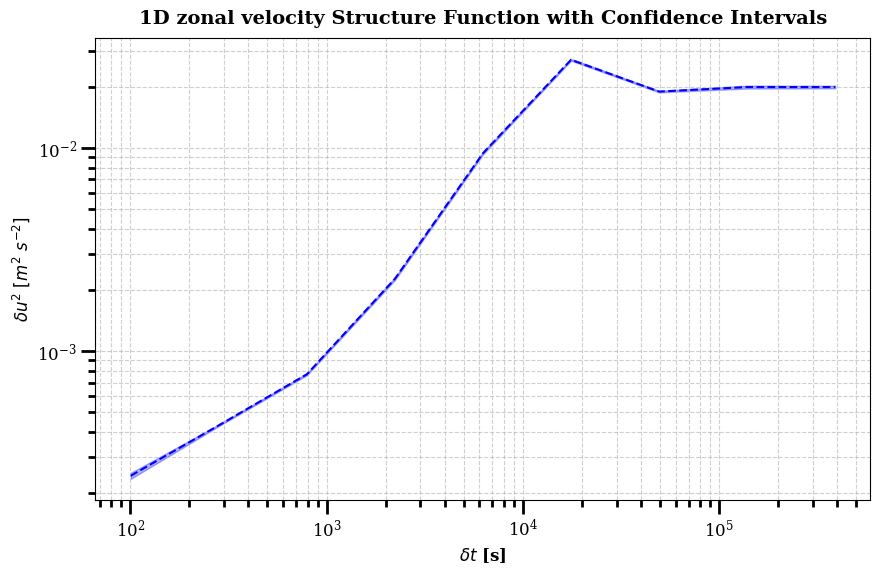

In [11]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.loglog(iso_sf_lon.bin, iso_sf_lon.sf, 'b--', linewidth=1.5)

plt.fill_between(iso_sf_lon.bin, 
                iso_sf_lon.ci_lower, 
                iso_sf_lon.ci_upper, 
                alpha=0.3, color='blue')



# Formatting
plt.xlabel(r'$\delta t$ [s]', fontsize=12, fontweight='bold')
plt.ylabel(r'$\delta u^{2}~[m^{2}~s^{-2}]$', fontsize=12, fontweight='bold')
plt.title('1D zonal velocity Structure Function with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)


## Physical Interpretation

The second-order structure function $S_2(\delta t) = \langle [u(t + \delta t) - u(t)]^2 \rangle$ measures the mean squared velocity difference as a function of time separation $\delta t$. Several key features are visible:

1. **Small separations ($\delta t < 10^4$ s):** The structure function increases with separation, indicating that velocity fluctuations become increasingly decorrelated at longer time lags. This reflects the turbulent nature of the flow.

2. **Intermediate scales:** The slope of $S_2(\delta t)$ in log-log space reveals the dominant dynamics. A slope close to 2/3 would suggest Kolmogorov-like scaling, while steeper slopes may indicate the influence of mesoscale eddies or internal waves.

3. **Large separations ($\delta t > 10^5$ s):** The structure function tends to plateau, approaching $2\sigma_u^2$ (twice the variance), as velocities at very long time lags become statistically independent.

4. **Confidence intervals:** The shaded region shows the bootstrap-derived uncertainty, which is narrow at small separations (many sample pairs) and widens at large separations (fewer independent samples).

This analysis reveals the characteristic timescales of turbulent energy transfer in the ocean, from sub-daily fluctuations to multi-day eddy motions.